In [13]:
#NLP Libraries:
import nltk
import spacy
#python -m spacy download en_core_web_sm

# import gensim
import textstat

#Our standards:
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import datetime
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import xgboost as xg

from sklearn.model_selection import train_test_split

sns.set("talk")

In [14]:
# data['log_price'].apply(lambda x: np.exp(x))

# data['description']

In [15]:
data = pd.read_csv('dataset/train.csv')

count = (data['beds'] == 0).sum()
data = data[data['beds'] != 0]
count = (data['beds'] == 0).sum()

# append a new column
numberOfWords = data['description'].str.split().apply(lambda x: len(x))

In [16]:
# data preperation
msk = np.random.rand(len(data)) <= 0.8

data['host_since'] = data['host_since'].fillna('2017-01-22')
data['first_review'] = data['first_review'].fillna('2017-01-22')
data['last_review'] = data['last_review'].fillna('2017-01-22')
data.host_since = pd.to_datetime(data.host_since, format='%Y-%m-%d')
data['host_since_in_years'] = datetime.datetime.now() - data['host_since']
data['host_since_in_years'] = data['host_since_in_years'].apply(lambda x: x.days)
data['host_since_in_years'] = data['host_since_in_years'].apply(lambda x: x/365)
data.host_since_in_years = pd.to_numeric(data.host_since_in_years)
data = data.drop('host_since', axis=1)

# first_review
data.first_review = pd.to_datetime(data.first_review, format='%Y-%m-%d')
data['first_review_in_years'] = datetime.datetime.now() - data['first_review']
data['first_review_in_years'] = data['first_review_in_years'].apply(lambda x: x.days)
data['first_review_in_years'] = data['first_review_in_years'].apply(lambda x: x/365)
data.first_review_in_years = pd.to_numeric(data.first_review_in_years)
data = data.drop('first_review', axis=1)

# last_review
data.last_review = pd.to_datetime(data.last_review, format='%Y-%m-%d')
data['last_review_in_years'] = datetime.datetime.now() - data['last_review']
data['last_review_in_years'] = data['last_review_in_years'].apply(lambda x: x.days)
data['last_review_in_years'] = data['last_review_in_years'].apply(lambda x: x/365)
data.last_review_in_years = pd.to_numeric(data.last_review_in_years)
data = data.drop('last_review', axis=1)

train = data[msk]
test = data[~msk]


binary_variables = ['cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']

categorical_variables = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city',
                         'neighbourhood', 'amenities']

numeric_variables = ['log_price', 'accommodates', 'bathrooms', 'host_response_rate', 'latitude', 'longitude',
                     'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'host_since_in_years',
                     'first_review_in_years', 'last_review_in_years']  

column_to_drop = ['id', 'name', 'thumbnail_url', 'zipcode']

columns = {'binary_variables': binary_variables, 'categorical_variables': categorical_variables,
           'numeric_variables': numeric_variables, 'column_to_drop': column_to_drop, 'binned_variables': []}

for column in columns['column_to_drop']:
    train = train.drop(column, axis=1)
    test = test.drop(column, axis=1)

for column in columns['binary_variables']:
    train[column] = train[column].apply(lambda x: True if x == 'TRUE' or x == 't' else False)
    test[column] = test[column].apply(lambda x: True if x == 'TRUE' or x == 't' else False)
    
train['host_response_rate'] = train['host_response_rate'].str.rstrip('%').astype('float') / 100.0
test['host_response_rate'] = test['host_response_rate'].str.rstrip('%').astype('float') / 100.0

for column in columns['numeric_variables']:
    train[column] = train[column].astype(float)
    test[column] = test[column].astype(float)
    
null_columns = []
for column in columns['binary_variables'] + columns['categorical_variables'] + columns['numeric_variables']:
    if train[column].isnull().sum():
        null_columns.append(column)
    if test[column].isnull().sum():
        null_columns.append(column)
        
avg_bath_per_accomm = (train['bathrooms']/train['accommodates']).mean()

train['bathrooms'] = train['bathrooms'].fillna(train['accommodates']*avg_bath_per_accomm)
test['bathrooms'] = test['bathrooms'].fillna(test['accommodates']*avg_bath_per_accomm)
null_columns = list(filter(lambda x : x!='bathrooms', null_columns))
avg_bedrooms_per_accomm = (train['bedrooms']/train['accommodates']).mean()

train['bedrooms'] = train['bedrooms'].fillna(train['accommodates']*avg_bedrooms_per_accomm)
test['bedrooms'] = test['bedrooms'].fillna(test['accommodates']*avg_bedrooms_per_accomm)
null_columns = list(filter(lambda x : x!='bedrooms', null_columns))
avg_beds_per_accomm = (train['beds']/train['accommodates']).mean()

train['beds'] = train['beds'].fillna(train['accommodates']*avg_beds_per_accomm)
test['beds'] = test['beds'].fillna(test['accommodates']*avg_beds_per_accomm)
null_columns = list(filter(lambda x : x!='beds', null_columns))


train_with_most_frequent_values = train.copy()
test_with_most_frequent_values = test.copy()
for column in null_columns:
    val = train_with_most_frequent_values[column].value_counts().index[0]
    train_with_most_frequent_values[column] = train_with_most_frequent_values[column].fillna(val)
    test_with_most_frequent_values[column] = test_with_most_frequent_values[column].fillna(val)

train = train_with_most_frequent_values
test = test_with_most_frequent_values

train = train.reset_index()
test = test.reset_index()

def collect_amenities(data, columns_dict):
    chars_to_remove = '"{}'
    amenities_set = set()
    for line in data['amenities']:
        amenities = line.split(',')
        for obj in amenities:
            for char in chars_to_remove:
                obj = obj.replace(char, "")
            if "translation missing" not in obj and obj != '':
                amenities_set.add(obj)
    for amenity in amenities_set:
        columns_dict['binary_variables'].append(amenity)
    return list(amenities_set)


def create_amenities_array(amenities_list, data):
    amenities_array = []
    for index, row in data.iterrows():
        array = np.zeros(shape=(len(amenities_list)))
        row_amen = data['amenities'][index].split(',')
        for amen in row_amen:
            item = amen.replace('"', '').replace('}', '').replace('{', '')
            if item in amenities_list:
                res = amenities_list.index(item)
                array[res] = 1
        amenities_array.append(array.tolist())

    amenities_df = pd.DataFrame(amenities_array, columns=amenities_list)
    return amenities_df


# converting amenities column to binary columns and updating columns_dict
def create_amenities_cols(data, amenities_set):
    amenities_array = create_amenities_array(amenities_set, data)

    data = data.drop(['amenities'], axis=1)
    data = pd.concat([data, amenities_array], axis=1)

    return data

amenities_list = collect_amenities(train, columns)
train = create_amenities_cols(train, amenities_list)
test = create_amenities_cols(test, amenities_list)
columns['categorical_variables'].remove('amenities')

top_neighbourhoods = train['neighbourhood'].value_counts().head(50).keys()
for index, row in train.iterrows():
    if row['neighbourhood'] not in top_neighbourhoods:
        train.at[index,'neighbourhood'] = 'other'
for index, row in test.iterrows():
    if row['neighbourhood'] not in top_neighbourhoods:
        test.at[index,'neighbourhood'] = 'other'
        
# we leave the target feature as is
oh_train = train['log_price']
oh_test = test['log_price']

# now adding the one hot encoded data
for variable in columns['binned_variables']+columns['categorical_variables']:
    onehot_train_col = pd.get_dummies(train[variable], prefix=variable)
    oh_train = pd.concat([oh_train, onehot_train_col], axis=1)

    onehot_test_col = pd.get_dummies(test[variable], prefix=variable)
    oh_test = pd.concat([oh_test, onehot_test_col], axis=1)
    
for col in columns['binary_variables']:
    train[col] = train[col].replace(True, 1)
    train[col] =train[col].replace(False, 0)
    oh_train = pd.concat([oh_train, train[col]], axis=1)

    test[col] = test[col].replace(True, 1)
    test[col] = test[col].replace(False, 0)
    oh_test = pd.concat([oh_test, test[col]], axis=1)
    
for col in columns['numeric_variables']:
    if col != 'log_price':
        oh_train = pd.concat([oh_train, train[col]], axis=1)
        oh_test = pd.concat([oh_test, test[col]], axis=1)
        
add_to_test = list(set(oh_train.columns) - set(oh_test.columns))
add_to_train = list(set(oh_test.columns) - set(oh_train.columns))
for col in add_to_train:
    oh_train[col] = 0
for col in add_to_test:
    oh_test[col] = 0

oh_test = oh_test[oh_train.columns]

/tmp/ipykernel_72790/375561499.py:182: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  oh_train[col] = 0
/tmp/ipykernel_72790/375561499.py:184: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  oh_test[col] = 0


<AxesSubplot:>

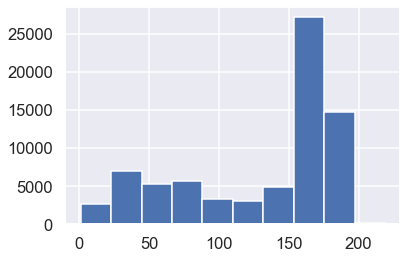

In [17]:
numberOfWords.hist()

/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


65024
9083
0.1649380464714172


/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


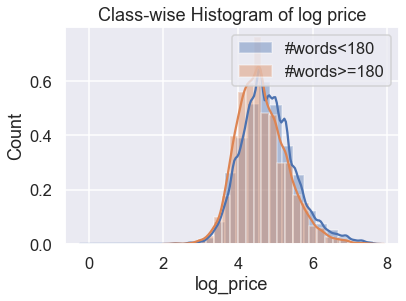

In [18]:
fig,ax=plt.subplots()

# maxDiff = 0

# for i in range(1,190):
#     lessWords = data[numberOfWords < i]
#     moreWords = data[numberOfWords >= i]
#     diff = np.abs(lessWords.mean() - moreWords.mean())
#     maxDiff = np.max(maxDiff, diff)

# print('max mean diff: ', maxDiff)

lessWords = data[numberOfWords < 180]
moreWords = data[numberOfWords >= 180]
sns.distplot(lessWords.log_price, bins = 25, kde = True, label = "#words<180",ax=ax)
sns.distplot(moreWords.log_price, bins = 25, kde = True, label = "#words>=180",ax=ax)

print(len(lessWords))
print(len(moreWords))
print(np.abs(lessWords.log_price.mean() - moreWords.log_price.mean()))

#Don't forget to make titles for the figure and axes
plt.title('Class-wise Histogram of log price')
plt.xlabel('log_price')
plt.ylabel('Count')
plt.legend(loc="upper right")

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

sentences_corpus = list(data["description"].values)
sentences_corpus[:5]

import nltk
from nltk.corpus import stopwords
# if not nltk.load('./stopWords'):
nltk.download('stopwords', 'stopWords/')
english_sw = stopwords.words('english')


singleCv = CountVectorizer(ngram_range=(1, 1),stop_words=english_sw)
singleVecs = singleCv.fit_transform(sentences_corpus)
singleSumBigrams = singleVecs.sum(axis=0)
singleSumSeries = pd.Series(singleSumBigrams.A1,index=list(singleCv.vocabulary_))
singleWordArr = singleSumSeries.sort_values(ascending=False).sort_values()[-10:]


doubleCv = CountVectorizer(ngram_range=(2, 2),stop_words=english_sw)
doubleVecs = doubleCv.fit_transform(sentences_corpus)
doubleSumBigrams = doubleVecs.sum(axis=0)
doubleSumSeries = pd.Series(doubleSumBigrams.A1,index=list(doubleCv.vocabulary_))
doubleWordArr = doubleSumSeries.sort_values(ascending=False).sort_values()[-10:]

[nltk_data] Downloading package stopwords to stopWords/...
[nltk_data]   Package stopwords is already up-to-date!


/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


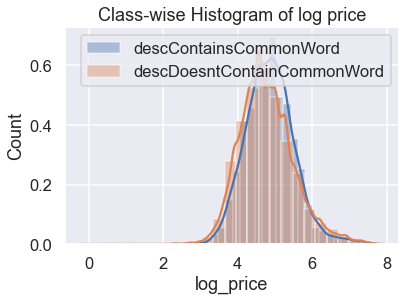

In [22]:
def isIn(arr : pd.core.series.Series, desc):
    for word in arr.keys():
        if word in desc:
            return 1
    return 0

train['isSingleCommonWordInDesc'] = train['description'].apply(lambda x: isIn(singleWordArr, x))

inDesc = train[train['isSingleCommonWordInDesc'] == 1]
notInDesc = train[train['isSingleCommonWordInDesc'] != 1]

fig,ax=plt.subplots()

sns.distplot(inDesc.log_price, bins = 25, kde = True, label = "descContainsCommonWord",ax=ax)
sns.distplot(notInDesc.log_price, bins = 25, kde = True, label = "descDoesntContainCommonWord",ax=ax)

#Don't forget to make titles for the figure and axes
plt.title('Class-wise Histogram of log price')
plt.xlabel('log_price')
plt.ylabel('Count')
plt.legend(loc="upper right")

/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/kobi/.local/lib/python3.10/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


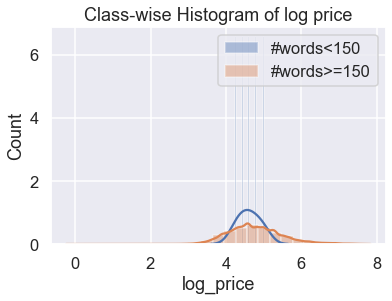

In [26]:
train['descContainDoubleCommonWord'] = train['description'].apply(lambda x: isIn(doubleWordArr, x))

inDesc = train[train['descContainsDoubleCommonWord'] == 1]
notInDesc = train[train['descContainDoubleCommonWord'] != 1]

fig,ax=plt.subplots()

sns.distplot(inDesc.log_price, bins = 25, kde = True, label = "containsDoubleCommonWord",ax=ax)
sns.distplot(notInDesc.log_price, bins = 25, kde = True, label = "doesntcontainDoubleCommonWord",ax=ax)

#Don't forget to make titles for the figure and axes
plt.title('Class-wise Histogram of log price')
plt.xlabel('log_price')
plt.ylabel('Count')
plt.legend(loc="upper right")

In [29]:
xgb_r = xg.XGBRegressor()
train_y = oh_train['log_price'].values
train_x = oh_train.drop('log_price', axis=1)
test_y = oh_test['log_price'].values
test_x = oh_test.drop('log_price', axis=1)

xgb_r = xg.XGBRegressor()

xgb_r.fit(train_x, train_y)

prediction_test = xgb_r.predict(test_x)

print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.3f}".format(mean_absolute_error(test_y, prediction_test)))
print("Mean Squared Error (Σ(|y-pred|/y)/n):",
      "{:,.3f}".format(mean_squared_error(test_y, prediction_test)))
print("Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)):", "{:,.3f}".
      format(np.sqrt(mean_squared_error(test_y, prediction_test))))
print("r2 score:", "{:,.3f}".format(r2_score(test_y, prediction_test)))

Mean Absolute Error (Σ|y-pred|/n): 0.270
Mean Squared Error (Σ(|y-pred|/y)/n): 0.139
Root Mean Squared Error (sqrt(Σ(y-pred)^2/n)): 0.373
r2 score: 0.727


## Future attempts
- Try LDA model (tokenize, clean etc) data before- group by mean data
- Check if price changes for a lot of adjectives, nouns in description etc.
- Try and use tfidf to measure how important certain words are (in regard to price).
